# Step 6 — Exploratory data analysis

This is the reviewed Step 6 notebook. It uses the three feature tables
created in Step 5 and keeps them separate because they describe different
startup populations.

It examines distributions, outliers, correlations, failure-factor
co-occurrence, and differences across sectors, stages, regions, and
observed outcomes. A short result note appears directly below every
analysis.

## Important interpretation rules

- The failure table contains **failed startups only**. Sector percentages
  describe recorded factors among failures; they are not sector failure rates.
- Crunchbase statuses are observed labels. `operating` does not prove
  profitability or long-term success.
- The startup-metrics table is **synthetic**. It demonstrates the method but
  does not estimate real-world startup rates.
- Correlation does not prove causation.
- Outliers are review candidates and are not automatically errors.

In [1]:
# Import the libraries used for tables and charts.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find the project folder whether the notebook is run from the project root
# or from the notebooks folder.
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"
TABLE_DIR = BASE_DIR / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Friendly names used in printed tables and charts.
VARIABLE_NAMES = {
    "funding_total_usd": "Total funding (USD)",
    "funding_rounds": "Funding rounds",
    "company_age_years": "Company age (years)",
    "funding_delay_months": "Time to first funding (months)",
    "funding_span_months": "Funding span (months)",
    "funding_raised_usd": "Funding raised (USD)",
    "operating_years": "Operating years",
    "failure_factor_count": "Recorded failure-factor count",
    "mrr_usd": "Monthly recurring revenue (USD)",
    "cac_usd": "Customer acquisition cost (USD)",
    "ltv_usd": "Customer lifetime value (USD)",
    "ltv_cac_ratio": "LTV / CAC ratio",
    "monthly_burn_usd": "Monthly burn (USD)",
    "cash_in_bank_usd": "Cash in bank (USD)",
    "runway_months": "Runway (months)",
}

FACTOR_NAMES = {
    "Giants": "Large incumbents",
    "No Budget": "No budget",
    "Competition": "Competition",
    "Poor Market Fit": "Poor market fit",
    "Acquisition Stagnation": "Acquisition stagnation",
    "Platform Dependency": "Platform dependency",
    "High Operational Costs": "High operational costs",
    "Monetization Failure": "Monetization failure",
    "Niche Limits": "Niche limits",
    "Execution Flaws": "Execution flaws",
    "Trend Shifts": "Trend shifts",
    "Toxicity/Trust Issues": "Toxicity / trust issues",
    "Regulatory Pressure": "Regulatory pressure",
    "Overhype": "Overhype",
}


def save_figure(file_name):
    # Save the current figure and show it in the notebook.
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()


def format_usd(value):
    # Make large dollar values easier to read.
    if pd.isna(value):
        return "Missing"
    if value >= 1_000_000_000:
        return f"${value / 1_000_000_000:.2f}B"
    if value >= 1_000_000:
        return f"${value / 1_000_000:.2f}M"
    if value >= 1_000:
        return f"${value / 1_000:.1f}K"
    return f"${value:,.0f}"

## 1. Load the Step 5 feature tables

The tables remain separate. They do not contain verified company-level
matches and should not be joined for this EDA.

In [2]:
failure_file = PROCESSED_DIR / "failure_feature_table.csv"
crunchbase_file = PROCESSED_DIR / "crunchbase_feature_table.csv"
metrics_file = PROCESSED_DIR / "startup_metrics_feature_table.csv"

required_files = [failure_file, crunchbase_file, metrics_file]
missing_files = [str(file) for file in required_files if not file.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing Step 5 files: {missing_files}. Run Step 5 first."
    )

failure = pd.read_csv(failure_file, low_memory=False)
crunchbase = pd.read_csv(crunchbase_file, low_memory=False)
metrics = pd.read_csv(metrics_file)

print(f"Failure table:        {len(failure):,} rows, {failure.shape[1]} columns")
print(f"Crunchbase table:     {len(crunchbase):,} rows, {crunchbase.shape[1]} columns")
print(f"Startup-metrics table: {len(metrics):,} rows, {metrics.shape[1]} columns")

Failure table:        409 rows, 36 columns
Crunchbase table:     66,368 rows, 26 columns
Startup-metrics table: 200 rows, 19 columns


**Result note.** The analysis has 409 failed-startup records, 66,368
Crunchbase company profiles, and 200 synthetic operating-metric records.
The large difference in sample size is another reason to analyze the tables
separately rather than treating them as one population.

## 2. Outliers

The IQR rule flags values outside 1.5 times the interquartile range. It is a
screening rule, not proof that a record is wrong.

In [3]:
def iqr_outlier_summary(table, columns, dataset_name):
    rows = []
    for column in columns:
        values = table[column].dropna()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((values < lower) | (values > upper)).sum()

        rows.append({
            "dataset": dataset_name,
            "variable": column,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outlier_count),
            "non_missing_count": len(values),
            "outlier_share_pct": 100 * outlier_count / len(values),
        })
    return pd.DataFrame(rows)


crunchbase_outliers = iqr_outlier_summary(
    crunchbase,
    [
        "funding_total_usd", "funding_rounds", "company_age_years",
        "funding_delay_months", "funding_span_months",
    ],
    "Crunchbase",
)

failure_outliers = iqr_outlier_summary(
    failure,
    ["funding_raised_usd", "operating_years", "failure_factor_count"],
    "Failure",
)

metrics_outliers = iqr_outlier_summary(
    metrics,
    [
        "mrr_usd", "cac_usd", "ltv_usd", "ltv_cac_ratio",
        "monthly_burn_usd", "cash_in_bank_usd", "runway_months",
    ],
    "Startup metrics",
)

outlier_summary = pd.concat(
    [crunchbase_outliers, failure_outliers, metrics_outliers],
    ignore_index=True,
)
outlier_summary.to_csv(
    TABLE_DIR / "step6_outlier_summary.csv", index=False
)

# Print the same results with business-friendly names.
outlier_display = outlier_summary.copy()
outlier_display["variable"] = outlier_display["variable"].map(VARIABLE_NAMES)
outlier_display = outlier_display.rename(columns={
    "dataset": "Dataset",
    "variable": "Variable",
    "lower_bound": "IQR lower boundary",
    "upper_bound": "IQR upper boundary",
    "outlier_count": "Outliers",
    "non_missing_count": "Observations",
    "outlier_share_pct": "Outlier share",
})
outlier_display["IQR lower boundary"] = outlier_display[
    "IQR lower boundary"
].map(lambda value: f"{value:,.2f}")
outlier_display["IQR upper boundary"] = outlier_display[
    "IQR upper boundary"
].map(lambda value: f"{value:,.2f}")
outlier_display["Outlier share"] = outlier_display[
    "Outlier share"
].map(lambda value: f"{value:.1f}%")

print(outlier_display.to_string(index=False))

        Dataset                        Variable IQR lower boundary IQR upper boundary  Outliers  Observations Outlier share
     Crunchbase             Total funding (USD)     -14,160,941.25      24,496,564.75      7384         53583         13.8%
     Crunchbase                  Funding rounds              -0.50               3.50      5937         66368          8.9%
     Crunchbase             Company age (years)              -7.50              20.50      2379         51141          4.7%
     Crunchbase  Time to first funding (months)             -55.85             111.75      4693         47360          9.9%
     Crunchbase           Funding span (months)             -20.55              34.25      7998         66342         12.1%
        Failure            Funding raised (USD)    -167,500,000.00     292,500,000.00        55           408         13.5%
        Failure                 Operating years              -2.50              17.50         3           409          0.7%
        

**Result note.** Total funding has the largest Crunchbase outlier share
(about 13.8%), followed by funding span (about 12.1%). Funding raised in
the failure data is also strongly skewed, with about 13.5% flagged. These
are plausible business extremes, so they should be inspected rather than
deleted automatically. Negative lower boundaries are produced by the IQR
formula; they do **not** mean the dataset contains negative funding.

## 3. Distributions

Funding is shown on a logarithmic scale because startup funding spans many
orders of magnitude. The underlying dollar values are unchanged.

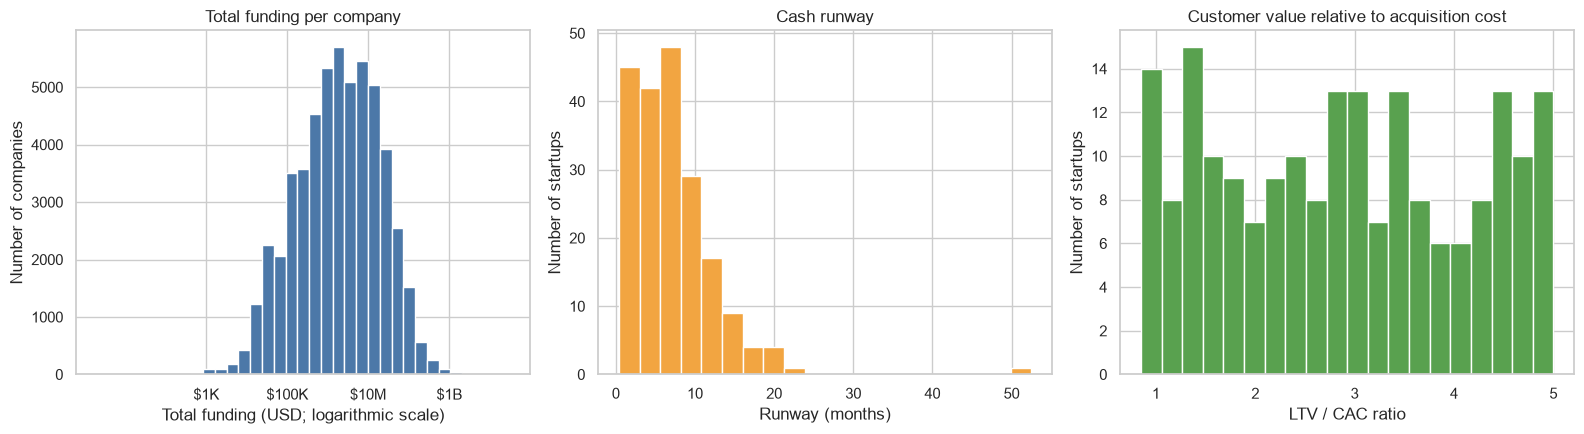

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Total funding: keep the log transformation but show readable dollar ticks.
funding_values = crunchbase["funding_total_usd"].dropna()
funding_log = np.log10(funding_values + 1)
axes[0].hist(funding_log, bins=35, color="#4C78A8", edgecolor="white")
axes[0].set_title("Total funding per company")
axes[0].set_xlabel("Total funding (USD; logarithmic scale)")
axes[0].set_ylabel("Number of companies")
axes[0].set_xticks([3, 5, 7, 9])
axes[0].set_xticklabels(["$1K", "$100K", "$10M", "$1B"])

axes[1].hist(
    metrics["runway_months"].dropna(),
    bins=20,
    color="#F2A541",
    edgecolor="white",
)
axes[1].set_title("Cash runway")
axes[1].set_xlabel("Runway (months)")
axes[1].set_ylabel("Number of startups")

axes[2].hist(
    metrics["ltv_cac_ratio"].dropna(),
    bins=20,
    color="#59A14F",
    edgecolor="white",
)
axes[2].set_title("Customer value relative to acquisition cost")
axes[2].set_xlabel("LTV / CAC ratio")
axes[2].set_ylabel("Number of startups")

save_figure("step6_01_distributions.png")

**Result note.** Funding varies across several orders of magnitude, which
confirms that medians and logarithmic charts are more informative than raw
averages alone. In the synthetic metrics, median runway is 6.4 months and
85.5% of startups have less than 12 months of runway; one record near 52.5
months creates the long right tail. The median LTV/CAC ratio is 2.87, but
its broad spread is a property of this synthetic sample—not evidence about
real startups.

## 4. Correlations

The first heatmap uses synthetic operating metrics. The second uses
Crunchbase funding and timing features.

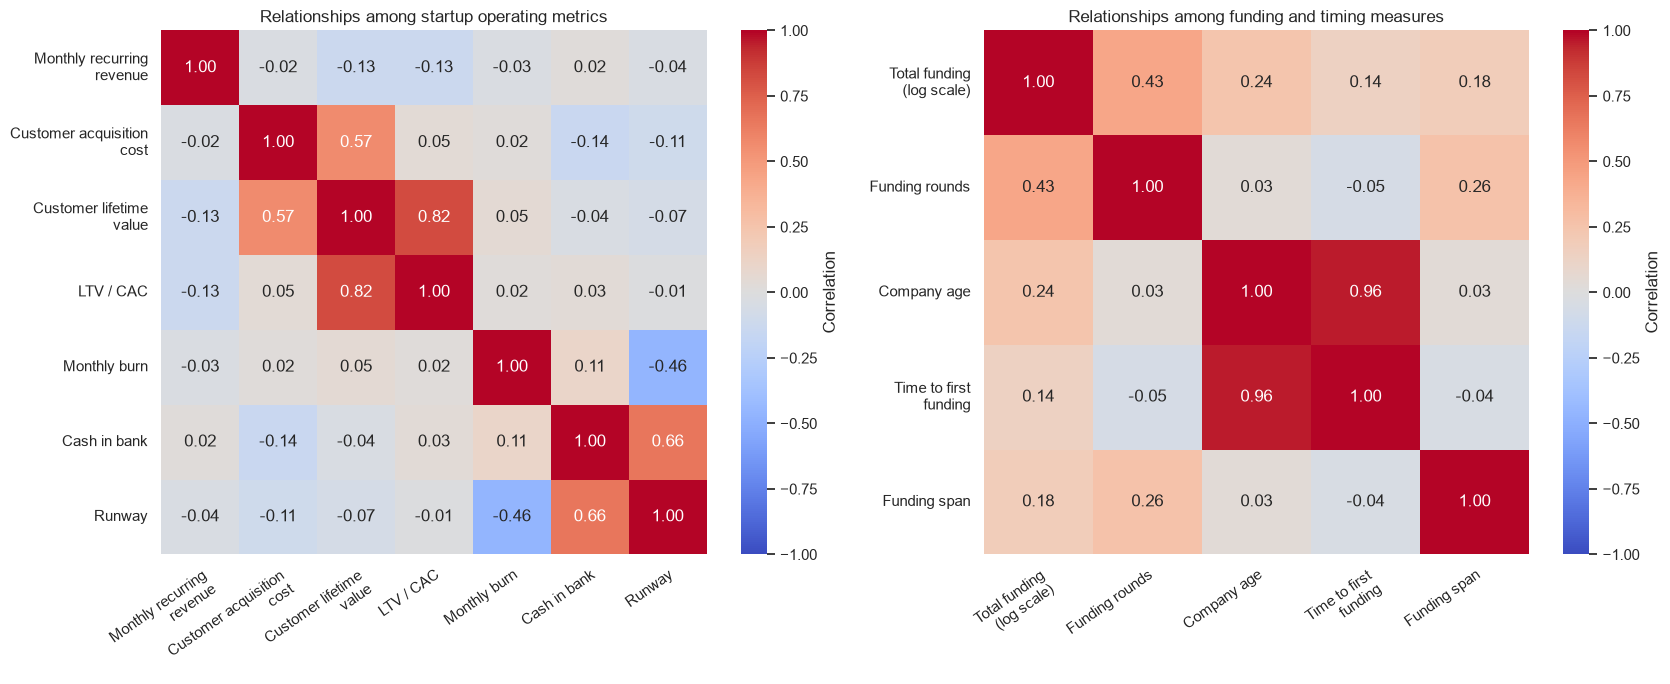

In [5]:
metrics_columns = [
    "mrr_usd", "cac_usd", "ltv_usd", "ltv_cac_ratio",
    "monthly_burn_usd", "cash_in_bank_usd", "runway_months",
]
metrics_correlation = metrics[metrics_columns].corr()

crunchbase_correlation_data = crunchbase[[
    "funding_rounds", "company_age_years",
    "funding_delay_months", "funding_span_months",
]].copy()
crunchbase_correlation_data.insert(
    0,
    "log10_funding",
    np.log10(crunchbase["funding_total_usd"] + 1),
)
crunchbase_correlation = crunchbase_correlation_data.corr()

# Short, readable labels for the heatmaps.
metric_labels = {
    "mrr_usd": "Monthly recurring\nrevenue",
    "cac_usd": "Customer acquisition\ncost",
    "ltv_usd": "Customer lifetime\nvalue",
    "ltv_cac_ratio": "LTV / CAC",
    "monthly_burn_usd": "Monthly burn",
    "cash_in_bank_usd": "Cash in bank",
    "runway_months": "Runway",
}
crunchbase_labels = {
    "log10_funding": "Total funding\n(log scale)",
    "funding_rounds": "Funding rounds",
    "company_age_years": "Company age",
    "funding_delay_months": "Time to first\nfunding",
    "funding_span_months": "Funding span",
}

metrics_plot = metrics_correlation.rename(
    index=metric_labels, columns=metric_labels
)
crunchbase_plot = crunchbase_correlation.rename(
    index=crunchbase_labels, columns=crunchbase_labels
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(
    metrics_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={"label": "Correlation"},
)
axes[0].set_title("Relationships among startup operating metrics")

sns.heatmap(
    crunchbase_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar_kws={"label": "Correlation"},
)
axes[1].set_title("Relationships among funding and timing measures")

for axis in axes:
    axis.tick_params(axis="y", rotation=0)
    plt.setp(
        axis.get_xticklabels(),
        rotation=35,
        ha="right",
        rotation_mode="anchor",
    )

save_figure("step6_02_correlations.png")

**Result note.** In the synthetic data, LTV and LTV/CAC correlate at 0.82,
cash and runway at 0.66, and burn and runway at −0.46. These are largely
expected because LTV/CAC and runway are calculated from those inputs. In
Crunchbase, funding rounds and funding span correlate at 0.77, while total
funding has moderate relationships with funding span (0.46) and funding
rounds (0.43). The 0.95 relationship between company age and time to first
funding likely reflects how the dates and observation window are defined;
it should not be treated as a causal discovery.

## 5. Failure-factor co-occurrence

Co-occurrence measures how often two recorded failure factors appear in the
same failed-startup record.

Most common individual factors:
         Failure factor  Records Share of failed startups
       Large incumbents      308                    75.3%
            Competition      291                    71.1%
 Acquisition stagnation       91                    22.2%
        Poor market fit       81                    19.8%
              No budget       77                    18.8%
           Niche limits       69                    16.9%
        Execution flaws       60                    14.7%
   Monetization failure       57                    13.9%
           Trend shifts       44                    10.8%
Toxicity / trust issues       23                     5.6%

Most common factor pairs:
    First factor          Second factor  Records together Share of failed startups
Large incumbents            Competition               238                    58.2%
Large incumbents Acquisition stagnation                73                    17.8%
     Competition Acquisition stagnation               

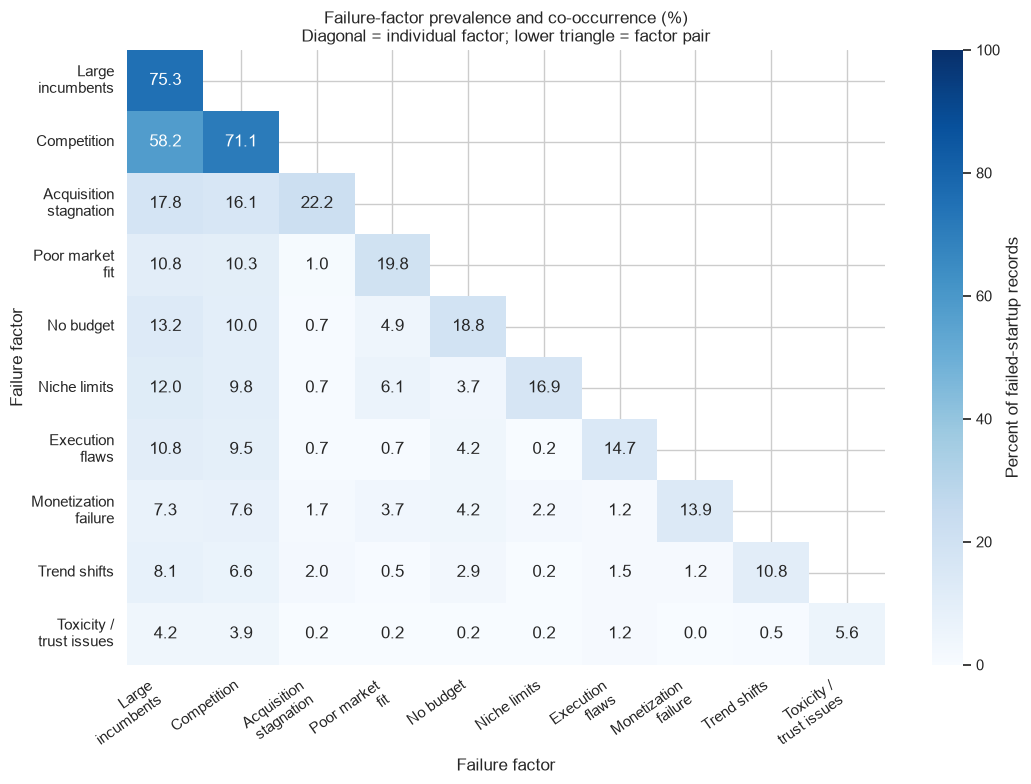

In [6]:
failure_flags = [
    "Giants", "No Budget", "Competition", "Poor Market Fit",
    "Acquisition Stagnation", "Platform Dependency",
    "High Operational Costs", "Monetization Failure", "Niche Limits",
    "Execution Flaws", "Trend Shifts", "Toxicity/Trust Issues",
    "Regulatory Pressure", "Overhype",
]

binary_flags = failure[failure_flags].eq(1).astype(int)
factor_frequency = binary_flags.sum().sort_values(ascending=False)
top_flags = factor_frequency.head(10).index.tolist()

# Pair table with both counts and percentages.
pair_rows = []
for position, first_flag in enumerate(failure_flags):
    for second_flag in failure_flags[position + 1:]:
        pair_count = (
            (failure[first_flag] == 1)
            & (failure[second_flag] == 1)
        ).sum()
        pair_rows.append({
            "factor_1": first_flag,
            "factor_2": second_flag,
            "cooccurrence_count": int(pair_count),
            "share_of_failures_pct": 100 * pair_count / len(failure),
        })

top_pairs = (
    pd.DataFrame(pair_rows)
    .sort_values("cooccurrence_count", ascending=False)
    .head(15)
)
top_pairs.to_csv(
    TABLE_DIR / "step6_top_failure_pairs.csv", index=False
)

frequency_display = pd.DataFrame({
    "Failure factor": [FACTOR_NAMES[name] for name in top_flags],
    "Records": factor_frequency.loc[top_flags].values,
    "Share of failed startups": [
        f"{100 * factor_frequency[name] / len(failure):.1f}%"
        for name in top_flags
    ],
})

pair_display = top_pairs.head(10).copy()
pair_display["factor_1"] = pair_display["factor_1"].map(FACTOR_NAMES)
pair_display["factor_2"] = pair_display["factor_2"].map(FACTOR_NAMES)
pair_display["share_of_failures_pct"] = pair_display[
    "share_of_failures_pct"
].map(lambda value: f"{value:.1f}%")
pair_display = pair_display.rename(columns={
    "factor_1": "First factor",
    "factor_2": "Second factor",
    "cooccurrence_count": "Records together",
    "share_of_failures_pct": "Share of failed startups",
})

print("Most common individual factors:")
print(frequency_display.to_string(index=False))
print()
print("Most common factor pairs:")
print(pair_display.to_string(index=False))

cooccurrence_pct = (
    binary_flags[top_flags].T.dot(binary_flags[top_flags])
    / len(failure)
    * 100
)

# Keep one triangle to avoid showing every pair twice.
mask = np.triu(np.ones_like(cooccurrence_pct, dtype=bool), k=1)
chart_labels = {
    "Giants": "Large\nincumbents",
    "Competition": "Competition",
    "Acquisition Stagnation": "Acquisition\nstagnation",
    "Poor Market Fit": "Poor market\nfit",
    "No Budget": "No budget",
    "Niche Limits": "Niche limits",
    "Execution Flaws": "Execution\nflaws",
    "Monetization Failure": "Monetization\nfailure",
    "Trend Shifts": "Trend shifts",
    "Toxicity/Trust Issues": "Toxicity /\ntrust issues",
}
cooccurrence_plot = cooccurrence_pct.rename(
    index=chart_labels, columns=chart_labels
)

plt.figure(figsize=(11, 8))
sns.heatmap(
    cooccurrence_plot,
    mask=mask,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Percent of failed-startup records"},
)
plt.title(
    "Failure-factor prevalence and co-occurrence (%)\n"
    "Diagonal = individual factor; lower triangle = factor pair"
)
plt.xlabel("Failure factor")
plt.ylabel("Failure factor")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
save_figure("step6_03_failure_cooccurrence.png")

**Result note.** Large incumbents appear in 75.3% of failed-startup
records and competition in 71.1%. They occur together in 238 records,
or 58.2% of the failure sample, making this the dominant recorded pair.
Because both factors are already very common, the pair count does not prove
that their combination is uniquely dangerous. It is best used as a common
diagnostic hypothesis to test with client evidence.

## 6. Differences across failure sectors

Percentages show the share of failed-startup records in each sector with a
factor recorded. They do not compare failures with surviving startups.

Recorded failure-factor count by sector:
                         Sector  Failed-startup records  Average factors  Median factors
Accommodation and Food Services                      26             3.04             3.0
          Finance and Insurance                      47             2.98             3.0
                    Health Care                      60             3.18             3.0
                    Information                     156             2.51             2.0
                  Manufacturing                      30             3.67             3.5
                   Retail Trade                      90             2.72             3.0


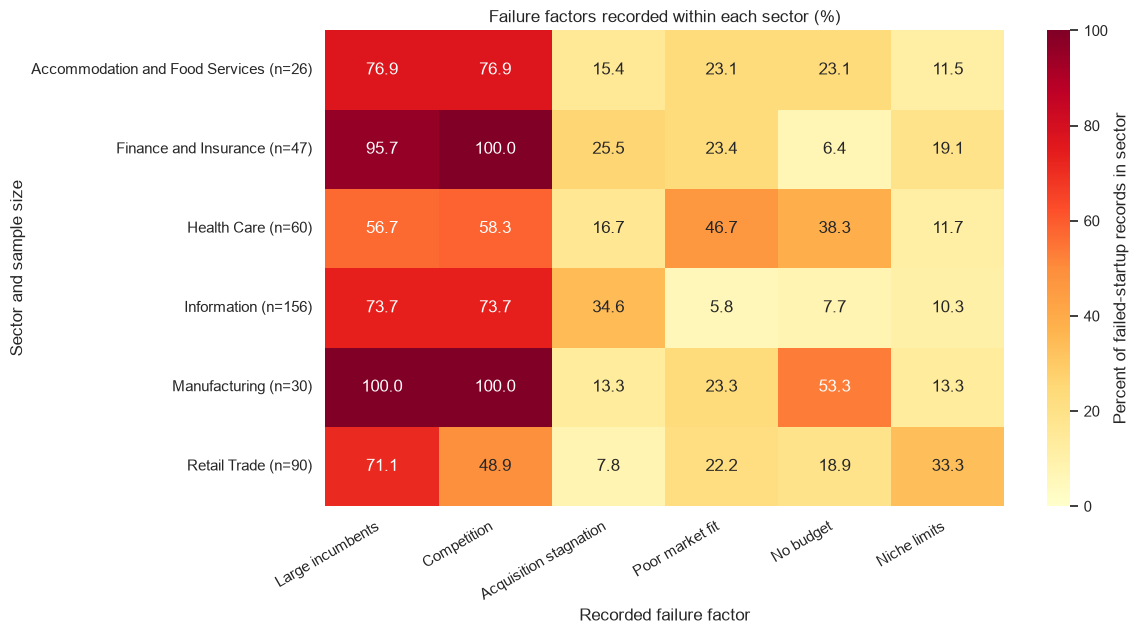

In [7]:
top_sector_flags = factor_frequency.head(6).index.tolist()
sector_prevalence = (
    failure.groupby("Sector")[top_sector_flags].mean() * 100
).round(1)

sector_factor_count = (
    failure.groupby("Sector")["failure_factor_count"]
    .agg(["count", "mean", "median"])
    .round(2)
)

sector_prevalence.to_csv(
    TABLE_DIR / "step6_sector_failure_prevalence.csv"
)
sector_factor_count.to_csv(
    TABLE_DIR / "step6_sector_factor_count.csv"
)

factor_count_display = sector_factor_count.reset_index().rename(columns={
    "Sector": "Sector",
    "count": "Failed-startup records",
    "mean": "Average factors",
    "median": "Median factors",
})
print("Recorded failure-factor count by sector:")
print(factor_count_display.to_string(index=False))

# Add sample size to every sector label and use readable factor names.
sector_plot = sector_prevalence.rename(columns=FACTOR_NAMES).copy()
sector_sizes = failure.groupby("Sector").size()
sector_plot.index = [
    f"{sector} (n={sector_sizes[sector]})"
    for sector in sector_plot.index
]

plt.figure(figsize=(12, 6.5))
sns.heatmap(
    sector_plot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Percent of failed-startup records in sector"},
)
plt.title("Failure factors recorded within each sector (%)")
plt.xlabel("Recorded failure factor")
plt.ylabel("Sector and sample size")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
save_figure("step6_04_sector_differences.png")

**Result note.** Manufacturing has the highest average number of recorded
factors (3.67), while Information has the lowest (2.51). Large incumbents
and competition appear in every Manufacturing record, and competition
appears in every Finance and Insurance record. Those sectors contain only
30 and 47 records, so the 100% values require caution. Health Care stands
out for poor market fit (46.7%) and no budget (38.3%), while Retail Trade
has the highest niche-limits share (33.3%). These are patterns among known
failures—not estimates of a sector's chance of failing.

## 7. Differences across startup stages

This section uses only the synthetic startup-metrics table.

Median operating metrics by stage:
   Stage  Median runway (months)  Median LTV / CAC Median monthly burn
Pre-Seed                     6.8              2.87              $24.0K
    Seed                     5.9              2.74              $24.6K
Series A                     6.2              3.04              $22.8K


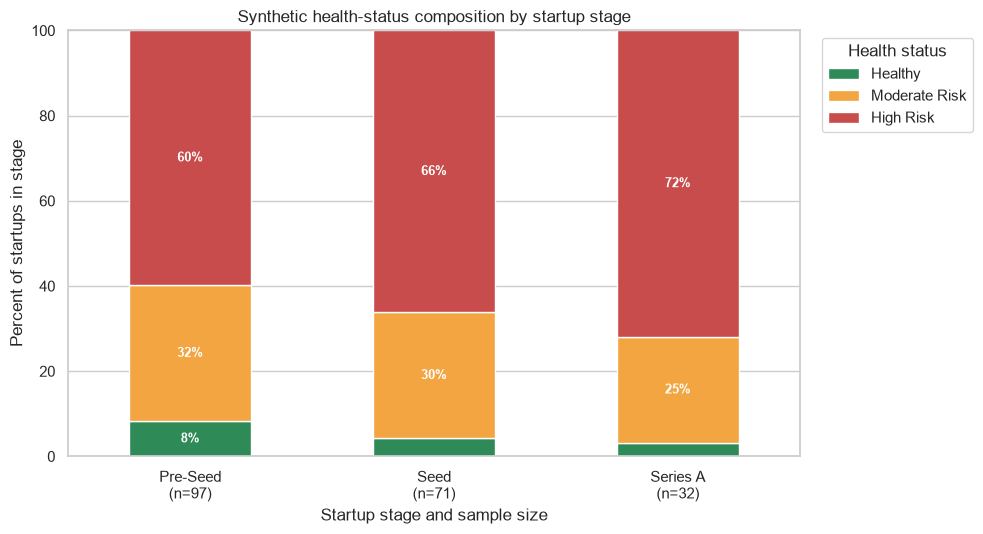

In [8]:
stage_order = [
    stage for stage in ["Pre-Seed", "Seed", "Series A"]
    if stage in metrics["stage"].unique()
]
health_order = ["Healthy", "Moderate Risk", "High Risk"]

stage_health = (
    pd.crosstab(
        metrics["stage"],
        metrics["health_status"],
        normalize="index",
    ) * 100
).reindex(index=stage_order, columns=health_order, fill_value=0)

stage_medians = (
    metrics.groupby("stage")[[
        "runway_months", "ltv_cac_ratio", "monthly_burn_usd"
    ]]
    .median()
    .reindex(stage_order)
    .round(2)
)

stage_health.to_csv(
    TABLE_DIR / "step6_stage_health_percent.csv"
)
stage_medians.to_csv(
    TABLE_DIR / "step6_stage_metric_medians.csv"
)

stage_display = stage_medians.reset_index().rename(columns={
    "stage": "Stage",
    "runway_months": "Median runway (months)",
    "ltv_cac_ratio": "Median LTV / CAC",
    "monthly_burn_usd": "Median monthly burn",
})
stage_display["Median monthly burn"] = stage_display[
    "Median monthly burn"
].map(format_usd)
print("Median operating metrics by stage:")
print(stage_display.to_string(index=False))

colors = ["#2E8B57", "#F2A541", "#C94C4C"]
ax = stage_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5.5),
    color=colors,
)
ax.set_title("Synthetic health-status composition by startup stage")
ax.set_xlabel("Startup stage and sample size")
ax.set_ylabel("Percent of startups in stage")
ax.set_ylim(0, 100)

stage_counts = metrics["stage"].value_counts()
ax.set_xticklabels(
    [f"{stage}\n(n={stage_counts[stage]})" for stage in stage_order],
    rotation=0,
)

# Label only segments large enough to read clearly.
for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

ax.legend(
    title="Health status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
save_figure("step6_05_stage_differences.png")

**Result note.** The synthetic High Risk share rises from 59.8% at
Pre-Seed to 66.2% at Seed and 71.9% at Series A. However, median runway
(5.9–6.8 months), LTV/CAC (2.74–3.04), and monthly burn
(approximately $22.8K–$24.6K) are fairly similar across stages. Series A
also has only 32 observations. In addition, **health_status** is an
engineered rule-based label, not an observed failure outcome. Therefore,
the chart demonstrates a diagnostic comparison but is not evidence that
risk genuinely increases with startup stage.

## 8. Differences across regions and observed outcomes

Unknown regions are excluded. The regional chart uses the ten regions with
the most company records.

Funding summary by observed company status:
Observed status  Companies with funding data Median funding Mean funding
      Operating                        42440         $1.52M      $13.93M
         Closed                         4912         $1.25M      $10.90M
       Acquired                         4790        $10.00M      $28.29M
            IPO                         1441        $30.68M     $145.71M


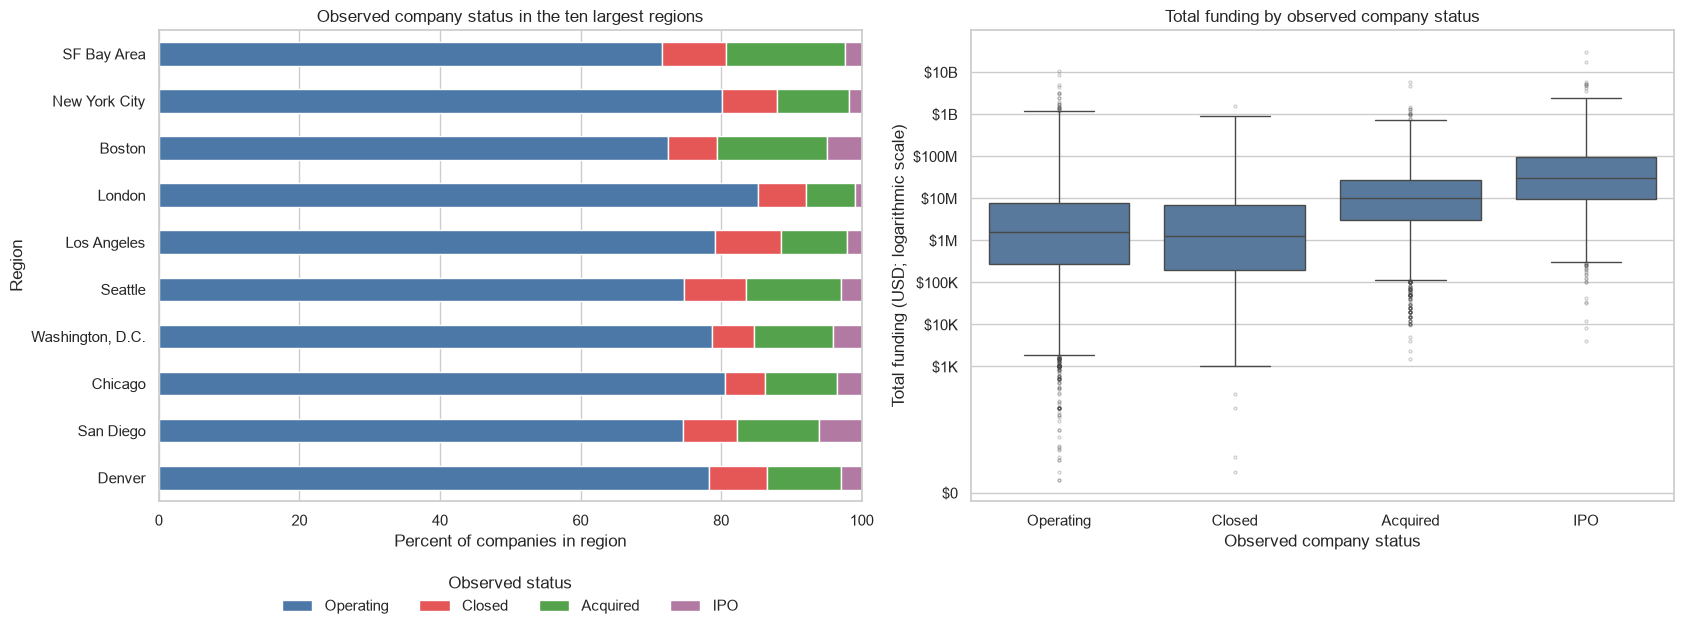

In [9]:
known_regions = crunchbase[crunchbase["region"] != "Unknown"]
top_regions = known_regions["region"].value_counts().head(10).index
status_order = ["operating", "closed", "acquired", "ipo"]

region_mask = known_regions["region"].isin(top_regions)
region_status = (
    pd.crosstab(
        known_regions.loc[region_mask, "region"],
        known_regions.loc[region_mask, "status"],
        normalize="index",
    ) * 100
).reindex(index=top_regions, columns=status_order, fill_value=0)

funding_by_status = (
    crunchbase.groupby("status")["funding_total_usd"]
    .agg(["count", "median", "mean"])
    .reindex(status_order)
)

region_status.to_csv(
    TABLE_DIR / "step6_region_status_percent.csv"
)
funding_by_status.to_csv(
    TABLE_DIR / "step6_status_funding_summary.csv"
)

funding_display = funding_by_status.reset_index().rename(columns={
    "status": "Observed status",
    "count": "Companies with funding data",
    "median": "Median funding",
    "mean": "Mean funding",
})
funding_display["Observed status"] = funding_display[
    "Observed status"
].str.title().replace({"Ipo": "IPO"})
funding_display["Median funding"] = funding_display[
    "Median funding"
].map(format_usd)
funding_display["Mean funding"] = funding_display[
    "Mean funding"
].map(format_usd)
print("Funding summary by observed company status:")
print(funding_display.to_string(index=False))

outcome_data = crunchbase.dropna(
    subset=["funding_total_usd"]
).copy()
outcome_data["funding_log"] = np.log10(
    outcome_data["funding_total_usd"] + 1
)
outcome_data["status_label"] = outcome_data["status"].map({
    "operating": "Operating",
    "closed": "Closed",
    "acquired": "Acquired",
    "ipo": "IPO",
})

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# Reverse the order so the largest region appears at the top.
region_plot = region_status.iloc[::-1]
region_plot.plot(
    kind="barh",
    stacked=True,
    ax=axes[0],
    color=["#4C78A8", "#E45756", "#54A24B", "#B279A2"],
)
axes[0].set_title("Observed company status in the ten largest regions")
axes[0].set_xlabel("Percent of companies in region")
axes[0].set_ylabel("Region")
axes[0].set_xlim(0, 100)
axes[0].legend(
    ["Operating", "Closed", "Acquired", "IPO"],
    title="Observed status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=4,
    frameon=False,
)

sns.boxplot(
    data=outcome_data,
    x="status_label",
    y="funding_log",
    order=["Operating", "Closed", "Acquired", "IPO"],
    ax=axes[1],
    color="#4C78A8",
    flierprops={
        "marker": "o",
        "markersize": 2,
        "alpha": 0.25,
    },
)
axes[1].set_title("Total funding by observed company status")
axes[1].set_xlabel("Observed company status")
axes[1].set_ylabel("Total funding (USD; logarithmic scale)")
axes[1].set_yticks([0, 3, 4, 5, 6, 7, 8, 9, 10])
axes[1].set_yticklabels([
    "$0", "$1K", "$10K", "$100K", "$1M",
    "$10M", "$100M", "$1B", "$10B",
])

save_figure("step6_06_regions_and_outcomes.png")

**Result note.** Operating companies are the largest status group in every
top region, ranging from 71.6% in the SF Bay Area to 85.2% in London.
The highest acquisition shares are in the SF Bay Area (16.9%) and Boston
(15.7%), while San Diego has the highest IPO share (6.1%). Median funding
rises from $1.25M for closed companies and $1.52M for operating companies
to $10.00M for acquired companies and $30.68M for IPO companies. Means are
much higher than medians, confirming strong right skew. The funding
comparison excludes the 12,785 companies with missing funding totals, so
missingness may affect the pattern. These are observed associations and may
reflect company age, reporting coverage, and selection effects—not a causal
funding threshold for success.

## Step 6 conclusion

The clearest exploratory findings are:

1. Funding variables are strongly skewed, so peer comparisons should use
   medians and funding bands rather than means alone.
2. Large incumbents and competition dominate the failure records, but their
   frequency may partly reflect coding and selection in post-mortems.
3. Sector patterns are useful for forming hypotheses, not estimating sector
   failure probability.
4. Several strong correlations are mechanical because one metric is
   calculated from another.
5. Outcome comparisons show associations only; observed status is not a
   complete measure of startup success.

Figures are saved in `outputs/figures`, and supporting tables are saved in
`outputs/tables`.